# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
cant_users = users.isna().sum()
proporcion_users = users.isna().mean()
# cantidad de nulos para users

print("Cantidad de valores nulos", cant_users)
print("Proporción de valores nulos", proporcion_users)


Cantidad de valores nulos user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
cant_usage = usage.isna().sum()
proporcion_usage = usage.isna().mean()
# cantidad de nulos para usage
print("Cantidad de valores nulos", cant_usage)
print("Proporción de valores nulos", proporcion_usage)

Cantidad de valores nulos id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  Tabla users

Columnas con nulos y proporción aproximada:

city: 11.7 % de valores nulos.

churn_date: 88.35 % de valores nulos.

Decisiones:

city (≈11.7 %): está entre 5 % y 30 %, así que investigaría la causa y probablemente imputaría (por ejemplo, usando la ciudad más frecuente por país/segmento) o la dejaría como nula si no es una variable clave para el modelo.

churn_date (≈88.35 %): tiene más del 80–90 % de nulos; esos nulos corresponden a usuarios que aún no han hecho churn, por lo que no imputaría la fecha y la usaría como indicador de churn (por ejemplo, creando una variable binaria is_churned), o bien ignoraría/eliminaría la columna de fecha si solo me interesa la variable derivada.

Tabla usage

Columnas con nulos y proporción aproximada:

date: 0.125 % de valores nulos (proporción 0.00125).

duration: 51.59 % de valores nulos (proporción 0.5159).

length: 44.74 % de valores nulos (proporción 0.4474).

Decisiones:

date: proporción <5 %; imputaría o directamente eliminaría esas pocas filas, porque son muy pocas y registros de uso sin fecha complican los análisis temporales.

duration: tiene más de la mitad de valores nulos; investigaría la razón y, si no es una variable clave o la medición es inconsistente, preferiría ignorar/eliminar la columna en lugar de imputar tanto dato faltante.

length: con 44.74 % de nulos, también está muy alta; al ser similar a duration, evaluaría si aporta valor al modelo y, salvo que sea muy relevante, también la ignoraría/eliminaría o aplicaría una imputación muy cautelosa y luego revisaría el impacto.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


La columna user_id
user_id es un identificador numérico que va de 10000 a 13999, con media cercana a 11999 y desviación estándar pequeña, por lo que los valores están repartidos de forma bastante uniforme dentro de ese rango. No muestra valores extremos ni variación relevante para el análisis, así que solo sirve como identificador y no como variable explicativa.

La columna age
age tiene edades entre −999 y 79 años, con media alrededor de 33.7 y cuartiles entre 32 y 63, lo que indica que la mayoría de usuarios son adultos jóvenes y de mediana edad. El valor mínimo de −999 es claramente un código erróneo o un marcador de dato faltante que habría que tratar (por ejemplo, imputar o marcar como nulo) antes de usar esta variable en el modelo.

In [13]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Las columnas id y user_id
id es solo un identificador de registro de uso: va de 1 a 40000, con media 20000 y una distribución uniforme, así que no aporta información útil para el comportamiento del usuario y se usaría solo como llave técnica. user_id identifica al usuario dueño de cada evento; sus valores están en el mismo rango que en la tabla users, y la media y los cuartiles indican que los registros de uso se reparten de forma razonablemente homogénea entre usuarios, por lo que sirve para hacer joins y análisis por usuario, pero no como variable numérica explicativa.
Las columnas duration y length
duration tiene una media alrededor de 5.2 minutos y una desviación estándar alta, con un máximo de 120, lo que indica una distribución muy dispersa con sesiones mucho más largas que el usuario promedio; esto sugiere la presencia de valores extremos (outliers) que sería importante revisar antes de modelar.

length tiene una media cercana a 52 y desviación estándar también alta, pero con un máximo de 1490, muy alejado del rango intercuartílico (entre 37 y 64), lo que apunta claramente a valores atípicos o posibles errores de captura; sería recomendable analizarlos (por ejemplo con boxplots o reglas basadas en IQR) y decidir si recortarlos, transformarlos o corregirlos.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n=== ANÁLISIS DE {col.upper()} ===")
    print("Valores únicos:")
    print(users[col].value_counts())
    print(f"\nTotal de valores únicos: {users[col].nunique()}")
    print(f"Valores nulos: {users[col].isnull().sum()}")


=== ANÁLISIS DE CITY ===
Valores únicos:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Total de valores únicos: 7
Valores nulos: 469

=== ANÁLISIS DE PLAN ===
Valores únicos:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Total de valores únicos: 2
Valores nulos: 0


La columna city
city tiene 7 valores únicos, principalmente grandes ciudades (Bogotá, CDMX, Medellín, GDL, Cali, MTY) y un valor “?” que probablemente representa datos desconocidos o mal capturados. La distribución está algo concentrada en unas pocas ciudades y además hay 469 nulos, así que conviene unificar el valor “?” con los nulos y decidir si imputar (por ejemplo, usando la ciudad más frecuente por país/segmento) o tratar “ciudad desconocida” como una categoría aparte en el modelo.

La columna plan
plan solo presenta dos categorías (Basico y Premium) sin valores nulos, lo que la convierte en una variable limpia y fácil de usar. Es una característica claramente relevante para el análisis, porque permite comparar el comportamiento de usuarios entre planes y posiblemente capturar diferencias de churn y uso entre ambos niveles de servicio.

In [15]:
# explorar columna categórica de usage
print("=== ANÁLISIS DE TYPE EN USAGE ===")
print("Tipos de uso:")
type_counts = usage['type'].value_counts()
type_percentages = usage['type'].value_counts(normalize=True) * 100

type_summary = pd.DataFrame({
    'Cantidad': type_counts,
    'Porcentaje': type_percentages.round(2)
})
print(type_summary)

=== ANÁLISIS DE TYPE EN USAGE ===
Tipos de uso:
      Cantidad  Porcentaje
text     22092       55.23
call     17908       44.77



La columna type
type distingue dos tipos de uso: text (55.23 %) y call (44.77 %), con una distribución relativamente equilibrada pero con algo más de actividades de texto que de llamadas. Esta variable es relevante porque permite comparar patrones de duración y frecuencia entre texto y llamadas, y podría explicar diferencias en el comportamiento de los usuarios o en el churn según el tipo de uso predominante.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
Valores inválidos o sentinels

Encontré un valor claramente inválido/sentinel en la columna age de users, donde aparece −999 como posible código para “edad desconocida” en lugar de un valor real.

También detecté un valor “?” en la columna categórica city, que funciona como código para “ciudad desconocida” y no como una ciudad válida.

Acciones recomendadas

Para age, reemplazaría el valor −999 por valores nulos (NaN) y luego aplicaría una estrategia de imputación adecuada (por ejemplo, imputar por mediana de edad por ciudad/plan) o excluiría esos registros si son pocos y el análisis lo permite.

Para city, unificaría el valor “?” con los nulos, tratándolo también como dato faltante; después decidiría si imputar (por ejemplo, usando la ciudad más frecuente en cada país/segmento) o mantener una categoría explícita de “ciudad desconocida” según lo que resulte más útil para el modelo.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = 'coerce') # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = 'coerce')# completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En reg_date de users aparecen registros entre 2022 y 2026; como el último año válido para el ejercicio es 2024, los registros con año 2026 parecen estar fuera de rango o haber sido capturados con una fecha errónea hacia el futuro.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64


En date de usage todos los registros están en 2024, por lo que no se observan años imposibles en esa columna.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
Fechas fuera de rango

Sí aparecen años imposibles en reg_date (2026), porque exceden el periodo de análisis definido (hasta 2024) y en la práctica representan fechas que “todavía no han ocurrido” en el contexto del ejercicio.

Para estos registros con año 2026, revisaría primero si hay un patrón de error (por ejemplo, que debieron ser 2023 o 2024) y, si no se puede corregir de forma confiable, los excluiría del análisis o ajustaría la fecha a nulo y los trataría como casos especiales en el preprocesamiento, ya que podrían distorsionar métricas de antigüedad y cohortes de registro.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage[['type', 'duration']].groupby('type')['duration'].apply(
    lambda x: x.isna().mean()
)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage[['type', 'length']].groupby('type')['length'].apply(
    lambda x: x.isna().mean()
)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

En duration, casi el 100 % de los registros de tipo text son nulos, mientras que en call no hay nulos; esto indica que la presencia de valores faltantes depende totalmente de type, por lo que no podemos asumir que los nulos sean MAR en el sentido clásico, sino que están condicionados a que el evento sea de texto (para textos no se mide duración).

En length ocurre lo contrario: casi todos los nulos aparecen en call y ninguno en text, así que nuevamente la falta de datos está completamente determinada por el tipo de uso; en las llamadas no se registra length, mientras que en los textos sí.

Dado que los nulos de duration y length reflejan el diseño del sistema de medición (qué se captura según el tipo de evento) más que errores aleatorios, los dejo como nulos y los interpreto como “no aplica” para ese tipo de uso, evitando imputar valores artificiales que mezclarían dos conceptos distintos (texto vs llamada); en el modelado posterior, puedo añadir indicadores binarios para “duration disponible” y “length disponible” o usar interacciones con type para capturar esta estructura.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage
    .groupby("user_id", as_index=False)
    .agg({
        "is_text": "sum",      # número total de mensajes
        "is_call": "sum",      # número total de llamadas
        "duration": "sum"      # total de minutos de llamadas
    })
)



In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on="user_id", how="left")

# Verificar combinación
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
cols_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

resumen_numerico_2024 = user_profile[cols_numericas].describe()
resumen_numerico_2024

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
plan_pct_2024 = (
    user_profile['plan']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plan_pct_2024

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

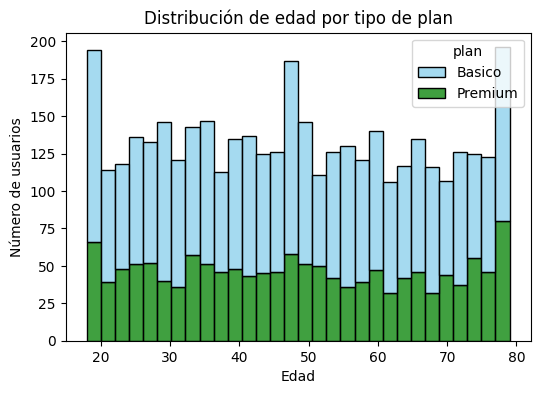

In [30]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(6,4))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    kde=False,
    bins=30,
    palette=['skyblue', 'green'],
    multiple='stack'
)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- La distribución de edad muestra varios picos visibles, especialmente alrededor de los 18 años, en la mitad de la vida (cerca de los 46) y hacia los 78, lo que sugiere una distribución multimodal más que uniforme. Tanto usuarios Básico como Premium aparecen en todos estos grupos etarios, por lo que, aunque hay concentraciones en ciertas edades, no se observa que un plan esté claramente asociado a un tramo de edad específico.

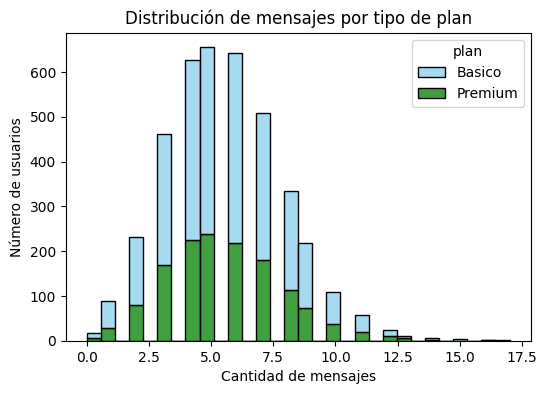

In [31]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(6,4))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    kde=False,
    bins=30,
    palette=['skyblue', 'green'],
    multiple='stack'
)
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- Los mensajes también se concentran en un rango acotado (aprox. 3 a 7 mensajes), con una distribución con cola a la derecha y muy pocos usuarios con volúmenes de mensajes muy altos.

La forma de la distribución es muy similar entre Básico y Premium; el plan Básico tiene más usuarios en todos los niveles de mensajes, pero no se ve un cambio drástico en la proporción relativa de “heavy texters” entre planes.

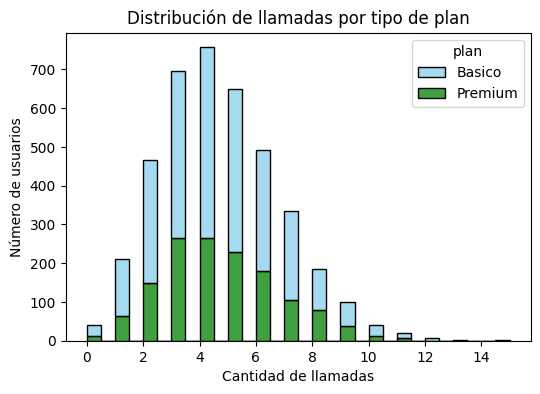

In [32]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(6,4))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    kde=False,
    bins=30,
    palette=['skyblue', 'green'],
    multiple='stack'
)
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- La cantidad de llamadas por usuario se concentra en un rango pequeño (alrededor de 3 a 7 llamadas), con una distribución aproximadamente unimodal y ligeramente sesgada a la derecha.

Tanto en el plan Básico como en el Premium el comportamiento es parecido: la mayoría de usuarios realiza pocas llamadas y solo unos pocos hacen muchas, por lo que no se aprecia una diferencia muy marcada en el patrón de llamadas entre planes.

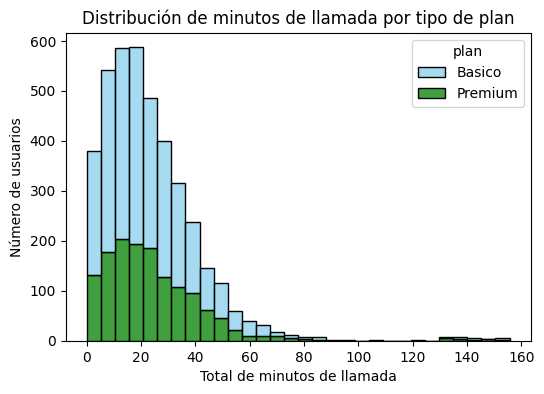

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(6,4))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    kde=False,
    bins=30,
    palette=['skyblue', 'green'],
    multiple='stack'
)
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights: 
- La distribución de minutos de llamada está claramente sesgada a la derecha: la mayoría de usuarios hace pocas llamadas (menos de 40 minutos totales) y solo unos pocos concentran muchos minutos.

En ambos planes, Básico y Premium, el patrón de forma es similar, aunque en términos absolutos hay más usuarios Básico en todos los rangos; no se observa un cambio fuerte de forma entre planes, solo de volumen.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

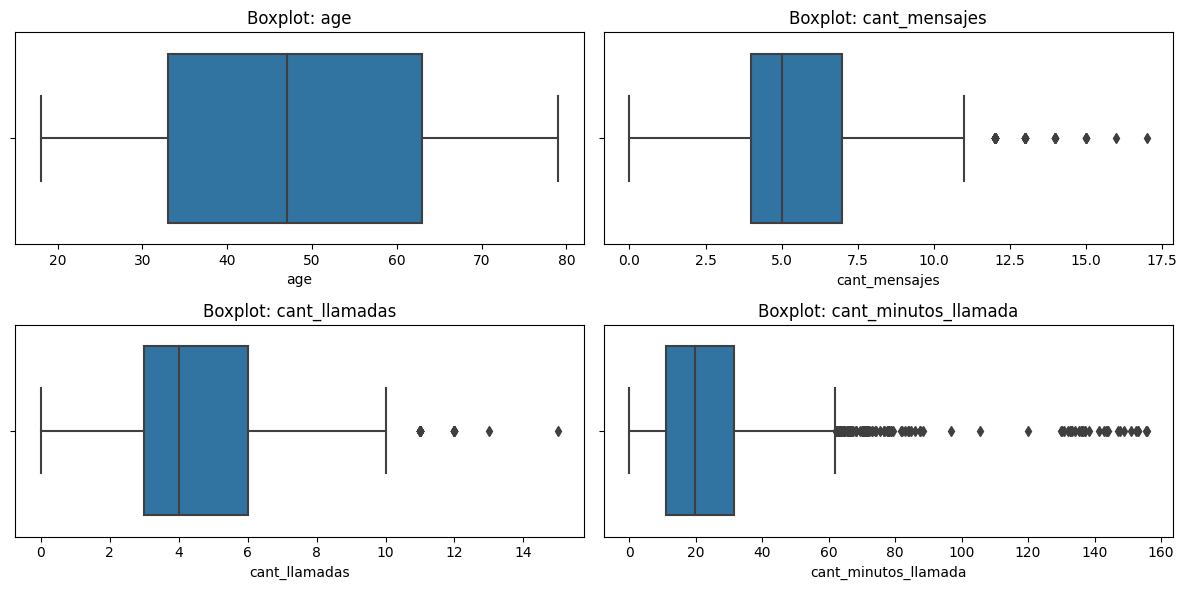

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(12, 6))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: El boxplot muestra varios outliers en la cola superior, es decir, algunos usuarios envían muchos más mensajes que el resto; estos casos representan “heavy users” de texto y, más que errores, parecen comportamientos reales, por lo que los conservaría y, si es necesario, aplicaría una transformación para reducir su impacto.

- cant_llamadas: También se observan outliers en la parte alta de la distribución (usuarios con muchas llamadas), aunque en menor cantidad que en mensajes; estos valores extremos podrían ser clientes con un patrón de uso intensivo de llamadas y, salvo que se detecte un error de captura, los mantendría como parte natural de la variabilidad.

- cant_minutos_llamada: Es la variable con más outliers, con algunos usuarios que acumulan muchos más minutos de llamada que el resto; estos valores pueden influir fuertemente en estadísticas como la media, por lo que valdría la pena revisarlos individualmente y considerar técnicas como winsorización o transformaciones logarítmicas si afectan demasiado a los modelos.

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

limites_iqr = {}

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    limites_iqr[col] = {
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'lower': lower,
        'upper': upper
    }

    print(f'\n=== {col} ===')
    print(f'Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}')
    print(f'Límite inferior: {lower:.2f}')
    print(f'Límite superior: {upper:.2f}')


=== cant_mensajes ===
Q1 = 4.00, Q3 = 7.00, IQR = 3.00
Límite inferior: -0.50
Límite superior: 11.50

=== cant_llamadas ===
Q1 = 3.00, Q3 = 6.00, IQR = 3.00
Límite inferior: -1.50
Límite superior: 10.50

=== cant_minutos_llamada ===
Q1 = 11.12, Q3 = 31.41, IQR = 20.30
Límite inferior: -19.32
Límite superior: 61.86


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  El límite superior IQR es 11.5 y el máximo observado es 17, es decir, los outliers están solo unos pocos mensajes por encima del rango típico. Dado que estos valores siguen siendo realistas para usuarios muy activos, conviene mantener los outliers de mensajes, tratándolos como clientes con uso intensivo en lugar de errores.
- cant_llamadas: mantener o no outliers, porqué?
  El límite superior es 10.5 y el máximo llega a 15 llamadas, por lo que los outliers de llamadas no se alejan de forma extrema del resto de la distribución. Estos valores pueden representar usuarios que llaman con mucha frecuencia, así que también mantendría los outliers de llamadas y, si hiciera falta, usaría métodos robustos o transformaciones para que no dominen el modelo.
- cant_minutos_llamada: mantener o no outliers, porqué?
  Aquí el límite superior es 61.86 minutos pero el máximo sube hasta 155.69, mostrando outliers bastante más alejados del rango típico. Aun así, los minutos no son absurdos (podrían ser usuarios que hablan mucho), por lo que mantendría estos outliers como casos de alto uso, aunque marcaría estos registros y consideraría transformaciones (por ejemplo logarítmica) o análisis de sensibilidad para asegurar que no distorsionen los resultados.



---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:

# Crear columna grupo_uso

cond_bajo = (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)
cond_medio = (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) & (~cond_bajo)

user_profile.loc[cond_bajo, 'grupo_uso'] = 'Bajo uso'
user_profile.loc[cond_medio, 'grupo_uso'] = 'Uso medio'
user_profile.loc[~(cond_bajo | cond_medio), 'grupo_uso'] = 'Alto uso'


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
cond_joven  = user_profile['age'] < 30
cond_adulto = (user_profile['age'] >= 30) & (user_profile['age'] < 60)

user_profile.loc[cond_joven,  'grupo_edad'] = 'Joven'
user_profile.loc[cond_adulto, 'grupo_edad'] = 'Adulto'
user_profile.loc[~(cond_joven | cond_adulto), 'grupo_edad'] = 'Adulto Mayor'

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

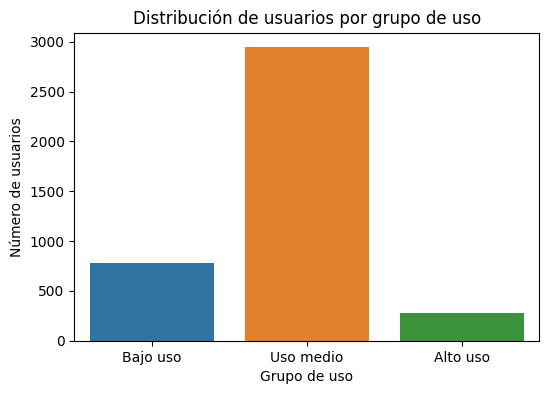

In [48]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')
plt.show()


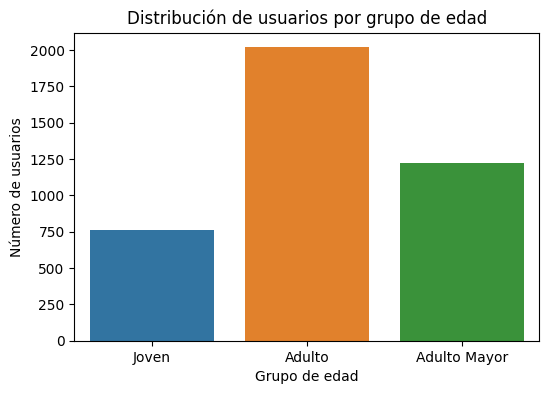

In [49]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')
plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Existían valores sentinels/ inválidos en age (−999) y en city ("?"), que se reinterpretaron como datos faltantes y se corrigieron mediante imputación o recodificación a nulos.

- Se encontraron fechas fuera de rango en reg_date (año 2026) respecto al horizonte válido (hasta 2024), que se marcaron como nulas para no distorsionar análisis de antigüedad.

- Las columnas duration y length tenían altos porcentajes de nulos dependientes del tipo de uso (type), por lo que se mantuvieron como “no aplica” en lugar de imputar masivamente y generar sesgos.

🔍 **Segmentos por Edad**
- La base está dominada por adultos: 2 018 de 3 , , , ,999 usuarios, lo que sugiere que la oferta actual está alineada con necesidades de personas en edad laboral y de mediana edad.

- El segmento de adulto mayor (1 222 usuarios) es grande y podría requerir comunicaciones y soporte adaptados (p. ej. canales más asistidos, planes simples), mientras que el segmento joven (760) es menor, pero estratégico para capturar clientes a largo plazo.

📊 **Segmentos por Nivel de Uso**
- El grupo de uso medio concentra la mayoría de clientes (2 943), lo que indica que los planes actuales atienden bien a un patrón de consumo moderado en llamadas y mensajes.

- El segmento de bajo uso (778 clientes) sugiere una oportunidad para planes más ligeros o esquemas de prepago que reduzcan el riesgo de churn de quienes usan poco el servicio.

- El grupo de alto uso (279 clientes) reúne a los heavy users de llamadas y mensajes; aunque son pocos, concentran muchos minutos y eventos, por lo que son candidatos naturales a planes Premium, bundles adicionales o programas de lealtad.

➡️ Esto sugiere que la mayoría de los clientes de ConnectaTel son de uso medio (2 943 usuarios), seguidos por un grupo menor de bajo uso (778) y un segmento pequeño pero relevante de alto uso (279).

En edad, predominan los adultos (2 018 usuarios), luego los adultos mayores (1 222) y, en menor medida, los jóvenes (760), lo que indica una base de clientes principalmente adulta con presencia importante de personas mayores.

**Patrones de outliers y su impacto**
- En mensajes y llamadas se detectaron usuarios con volúmenes muy por encima del rango típico (por encima de los límites IQR), pero con valores plausibles, que se interpretan como clientes de alto uso más que como errores.

- En minutos de llamada los outliers son más extremos (máximos muy por encima del límite superior), indicando una minoría de clientes que habla muchísimo; estos casos pueden sesgar métricas agregadas, por lo que conviene usar estadísticas robustas o transformaciones al modelar.

- No se observaron outliers absurdos en edad tras limpiar el sentinel; los extremos se mantienen porque representan edades posibles y ayudan a entender mejor todos los rangos de clientes.

💡 **Recomendaciones**
- Diseñar o ajustar planes específicos para bajo uso, con menor renta fija y beneficios enfocados en mantener a estos clientes activos sin que sientan que “pagan de más”.

- Fortalecer la propuesta de valor para el segmento de alto uso (minutos y mensajes): paquetes ilimitados, descuentos por volumen o beneficios adicionales que reduzcan el incentivo a migrar a la competencia.

- Crear campañas diferenciadas por grupo de edad (jóvenes vs adultos vs adultos mayores), adaptando canales y mensajes: digitales y promocionales para jóvenes, propuestas de valor estables y de servicio para adultos y adultos mayores.

- Al modelar churn o valor de cliente, usar métodos robustos a outliers (o transformaciones) en variables de uso, manteniendo los casos extremos como señal de clientes de alto valor en lugar de eliminarlos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`